In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [3]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


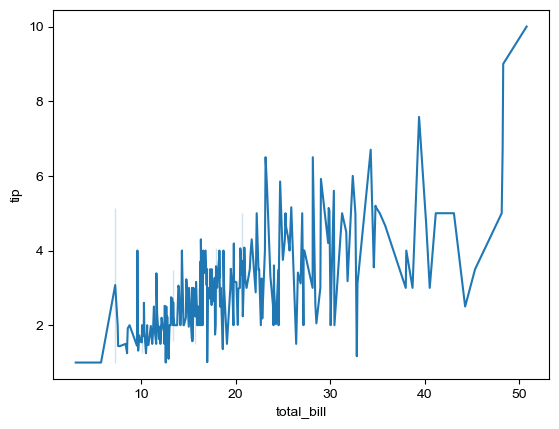

In [4]:
sns.lineplot(data=tips, # choose our dataset
x='total_bill'
, # define our x variable
y='tip') # define our y variable
sns.set_style('whitegrid')

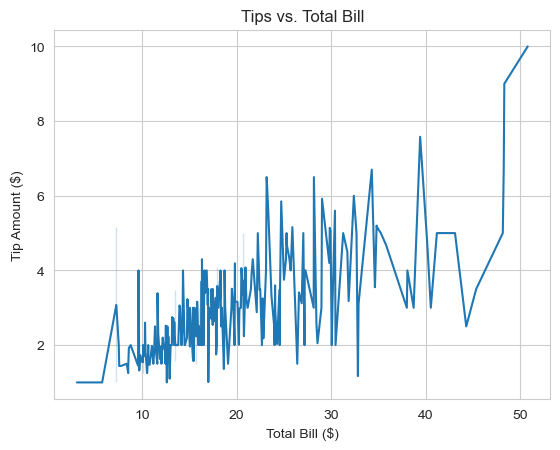

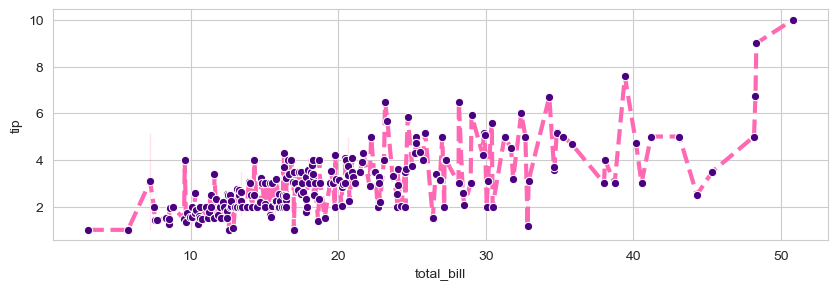

In [5]:

tipgraph = sns.lineplot(data=tips, x='total_bill', y='tip')
tipgraph.set(title='Tips vs. Total Bill', xlabel='Total Bill ($)', ylabel='Tip Amount ($)')

fig = plt.subplots(figsize=(10, 3))
tipgraph = sns.lineplot(data=tips,
                       x='total_bill',
                       y='tip',
                       color='hotpink',
                       linestyle='--',
                       linewidth=3,
                       marker='o',
                       markerfacecolor='indigo')

# Show the plot
plt.show()



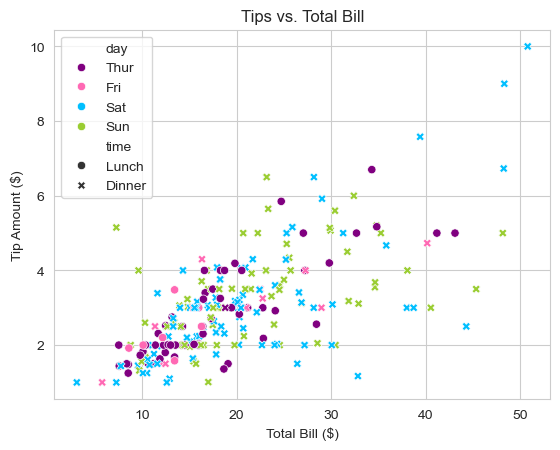

In [6]:
tipgraph = sns.scatterplot(
    data=tips, 
    x='total_bill',
    y='tip',
    style='time',  # Make sure 'time' exists in your dataset
    hue='day', 
    palette=['purple', 'hotpink', 'deepskyblue', 'yellowgreen']
)

# Set the title and labels
tipgraph.set(
    title='Tips vs. Total Bill',
    xlabel='Total Bill ($)',
    ylabel='Tip Amount ($)'
)

# Show the plot
plt.show()

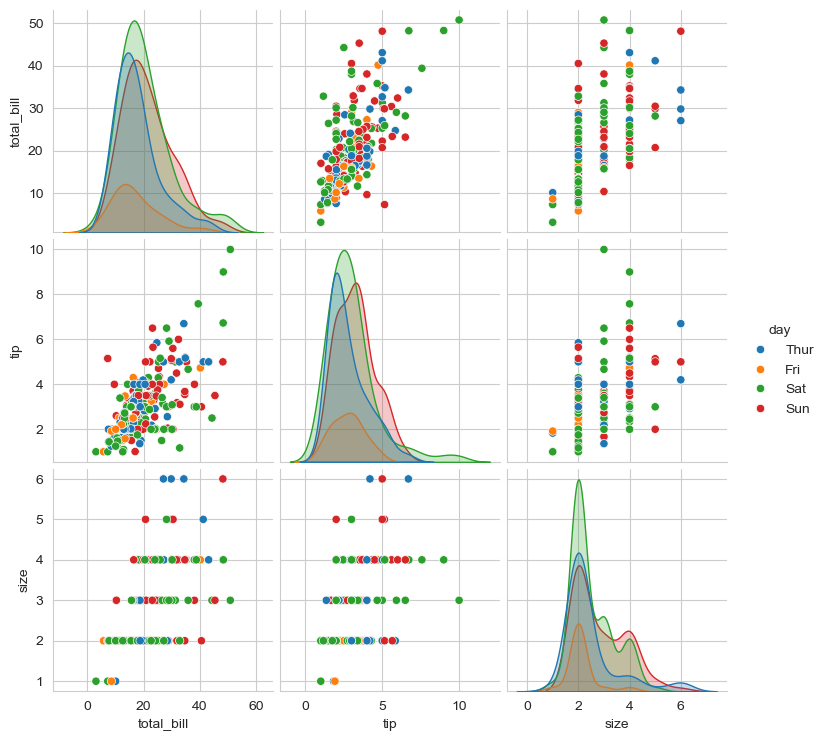

In [7]:
sns.pairplot(
data = tips,
hue = 'day')


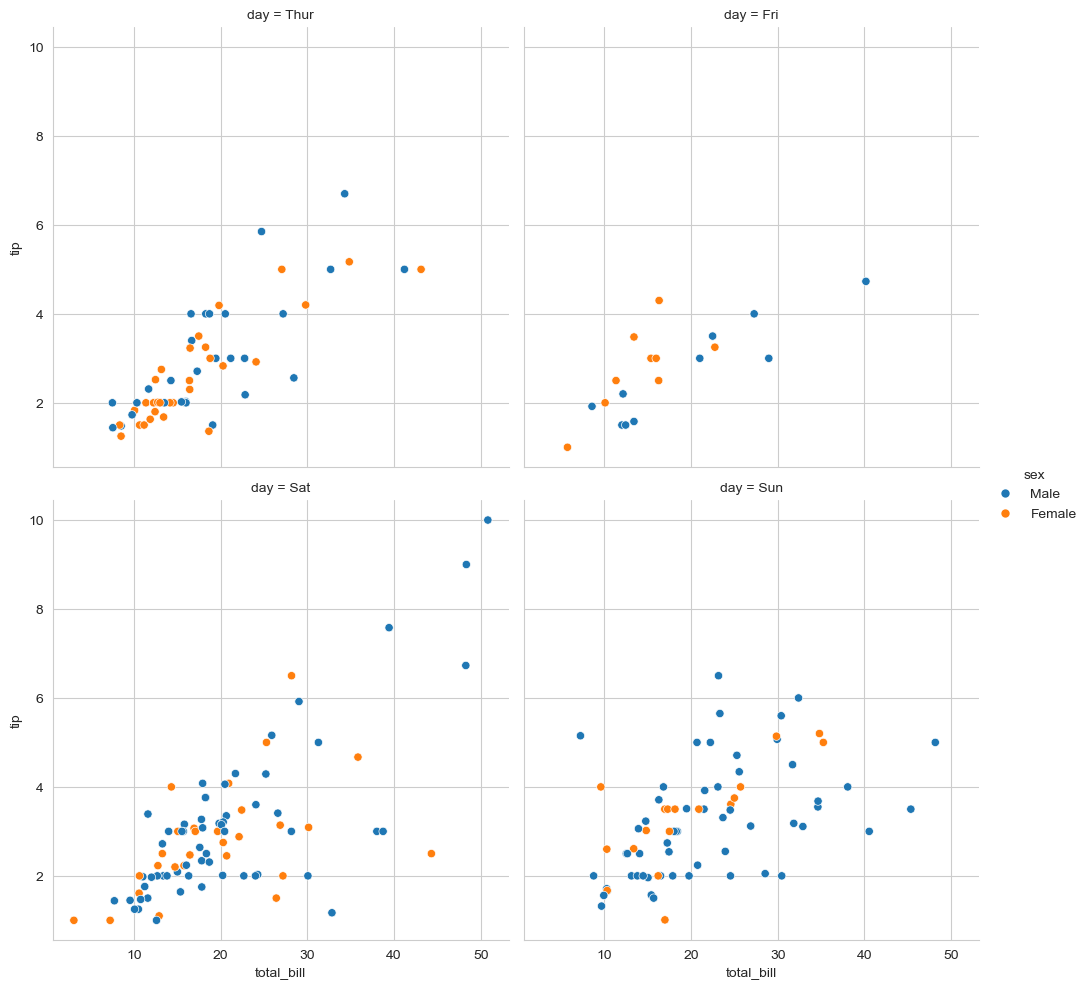

In [8]:
# Create the scatter plot using relplot
daysplot = sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",    # Color points by 'sex'
    col="day",    # Create separate plots for each 'day'
    kind="scatter",  # Scatter plot type
    col_wrap=2     # Wrap the plots into two columns
)

# Show the plot
plt.show()

In [10]:
# Define data for the plot
import plotly.graph_objects as go
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

# Create the bar chart
fig = go.Figure(data=[go.Bar(x=x1, y=y1)])

# Update layout with a title and axis labels
fig.update_layout(
    title="Character Strengths",
    xaxis_title="Character",
    yaxis_title="Strength"
)

# Show the plot
fig.show()


In [11]:
graph = go.Figure()
graph.add_trace(go.Scatter(
    x=x1, 
    y=y1, 
    mode='markers',  # We want points for a scatter plot
    marker=dict(
        size=15,           # Point size
        color='hotpink',   # Point color
        opacity=1,         # Point transparency/alpha
        line=dict(width=5, color='purple')  # Point outline
    )
))



In [13]:
from wordcloud import WordCloud

# Load the CSV file from the URL into a DataFrame
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv", on_bad_lines='skip')

# Display the first few rows of the DataFrame to check the contents
print(df.head())


                                               quote  \
0                    Do, or do not. There is no try.   
1  Listen to them. Children of the night. What mu...   
2                            It's alive! It's alive!   
3  Oh, no, it wasn't the airplanes. It was Beauty...   
4  Magic Mirror on the wall, who is the fairest o...   

                                            movie   type  year  
0  Star Wars: Episode V - The Empire Strikes Back  movie  1890  
1                                         Dracula  movie  1931  
2                                    Frankenstein  movie  1931  
3                                       King Kong  movie  1933  
4                Snow White and the Seven Dwarves  movie  1937  


(-0.5, 399.5, 199.5, -0.5)

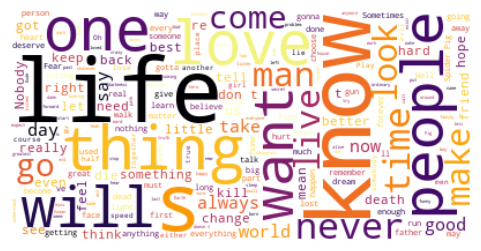

In [14]:
text = " ".join(each for each in df.quote)

# Generate the word cloud
wordcloud = WordCloud(background_color="white", colormap='inferno').generate(text)

# Use matplotlib to display the word cloud image
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation='bilinear')  # Helps smooth the image
ax.axis("off")  # Turn off the axis


In [17]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted


c:\Users\laure\miniconda3\envs\dsi_participant\lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



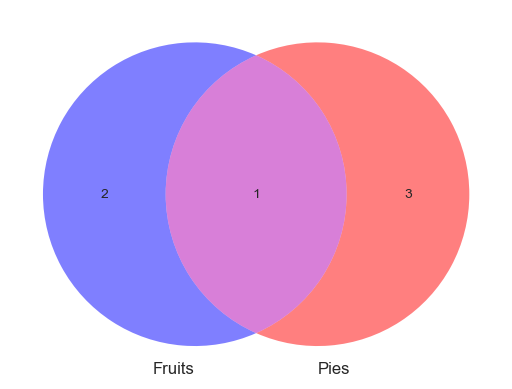

In [18]:
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2_unweighted([A, B],
                        set_labels = ('Fruits','Pies'),
                        set_colors=("blue","red"),
                        alpha=0.5)
plt.show()


In [20]:
# Assuming 'diagram' is a Venn diagram object (e.g., from matplotlib_venn)
diagram.get_label_by_id("10").set_text("\n".join(A - B))  # Elements in A but not in B
diagram.get_label_by_id("11").set_text("\n".join(A & B))  # Elements in both A and B (intersection)
diagram.get_label_by_id("01").set_text("\n".join(B - A))  # Elements in B but not in A
plt.show()